In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
np.random.seed(42)

n = 200

data = {
    "CGPA": np.round(np.random.uniform(5.5, 9.8, n), 2),
    "Attendance": np.random.randint(60, 101, n),
    "Aptitude": np.random.randint(40, 101, n),
    "Technical_Skills": np.random.randint(40, 101, n),
    "Communication_Skills": np.random.randint(40, 101, n),
    "Internship": np.random.randint(0, 2, n)
}

df = pd.DataFrame(data)

score = (
    df["CGPA"] * 10
    + df["Attendance"] * 0.20
    + df["Aptitude"] * 0.25
    + df["Technical_Skills"] * 0.30
    + df["Communication_Skills"] * 0.15
    + df["Internship"] * 10
)

df["Placed"] = (score >= 125).astype(int)

print("Dataset created successfully!")

Dataset created successfully!


In [3]:
df.head(10)

,CGPA,Attendance,Aptitude,Technical_Skills,Communication_Skills,Internship,Placed
0,7.11,83,79,100,49,1,1
1,9.59,70,49,86,95,0,1
2,8.65,67,82,60,56,1,1
3,8.07,95,83,55,49,1,1
4,6.17,97,68,93,56,1,1
5,6.17,99,52,60,99,0,1
6,5.75,79,51,50,59,1,0
7,9.22,94,70,99,63,0,1
8,8.08,84,85,76,44,1,1
9,8.54,94,41,75,73,0,1


In [4]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (200, 7)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CGPA                  200 non-null    float64
 1   Attendance            200 non-null    int32  
 2   Aptitude              200 non-null    int32  
 3   Technical_Skills      200 non-null    int32  
 4   Communication_Skills  200 non-null    int32  
 5   Internship            200 non-null    int32  
 6   Placed                200 non-null    int64  
dtypes: float64(1), int32(5), int64(1)
memory usage: 7.2 KB


In [5]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CGPA                    0
Attendance              0
Aptitude                0
Technical_Skills        0
Communication_Skills    0
Internship              0
Placed                  0
dtype: int64


In [6]:
df.describe()

,CGPA,Attendance,Aptitude,Technical_Skills,Communication_Skills,Internship,Placed
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,7.580800,81.380000,71.015000,70.160000,69.695000,0.470000,0.895000
std,1.268133,11.603396,17.310199,17.852675,17.946094,0.500352,0.307323
min,5.520000,60.000000,40.000000,40.000000,40.000000,0.000000,0.000000
25%,6.480000,72.000000,56.000000,55.000000,54.750000,0.000000,1.000000
50%,7.625000,83.000000,71.000000,70.000000,68.500000,0.000000,1.000000
75%,8.755000,92.000000,85.250000,87.000000,86.000000,1.000000,1.000000
max,9.740000,100.000000,100.000000,100.000000,100.000000,1.000000,1.000000


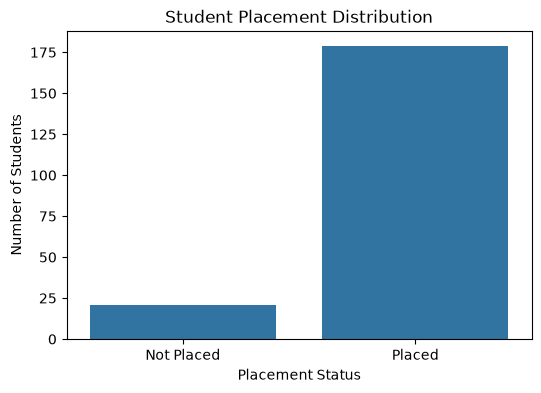

In [7]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Placed", data=df)

plt.title("Student Placement Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.xticks([0, 1], ["Not Placed", "Placed"])

plt.show()

In [8]:
X = df[
    [
        "CGPA",
        "Attendance",
        "Aptitude",
        "Technical_Skills",
        "Communication_Skills",
        "Internship"
    ]
]

y = df["Placed"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   CGPA  Attendance  Aptitude  Technical_Skills  Communication_Skills  \
0  7.11          83        79               100                    49   
1  9.59          70        49                86                    95   
2  8.65          67        82                60                    56   
3  8.07          95        83                55                    49   
4  6.17          97        68                93                    56   

   Internship  
0           1  
1           0  
2           1  
3           1  
4           1  

Target:
0    1
1    1
2    1
3    1
4    1
Name: Placed, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 160
Testing Samples : 40


In [10]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [11]:
model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [12]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1
 1 1 1]


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 97.5 %


In [14]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Placed", "Placed"]
    )
)

Classification Report:

              precision    recall  f1-score   support

  Not Placed       1.00      0.75      0.86         4
      Placed       0.97      1.00      0.99        36

    accuracy                           0.97        40
   macro avg       0.99      0.88      0.92        40
weighted avg       0.98      0.97      0.97        40



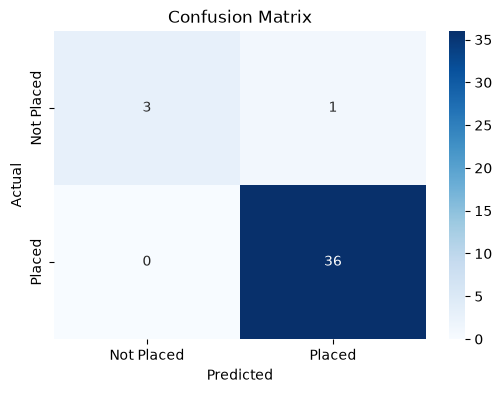

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                Feature  Importance
0                  CGPA    0.357751
3      Technical_Skills    0.239277
1            Attendance    0.143949
2              Aptitude    0.131218
4  Communication_Skills    0.090009
5            Internship    0.037795


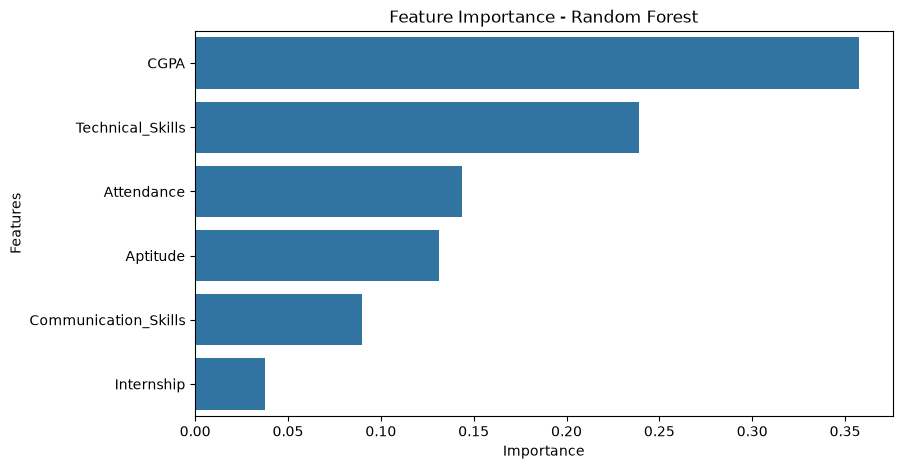

In [17]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [18]:
new_student = pd.DataFrame({
    "CGPA": [8.6],
    "Attendance": [92],
    "Aptitude": [88],
    "Technical_Skills": [90],
    "Communication_Skills": [86],
    "Internship": [1]
})

prediction = model.predict(new_student)
probability = model.predict_proba(new_student)

print("NEW STUDENT DETAILS")
print("-------------------------")

print("CGPA:", new_student["CGPA"].iloc[0])
print("Attendance:", new_student["Attendance"].iloc[0], "%")
print("Aptitude:", new_student["Aptitude"].iloc[0])
print("Technical Skills:", new_student["Technical_Skills"].iloc[0])
print("Communication Skills:", new_student["Communication_Skills"].iloc[0])
print("Internship:", "Yes" if new_student["Internship"].iloc[0] == 1 else "No")

print("\nPLACEMENT PREDICTION")
print("-------------------------")

if prediction[0] == 1:
    print("Prediction: PLACED")
    print("Placement Probability:",
          round(probability[0][1] * 100, 2), "%")
else:
    print("Prediction: NOT PLACED")
    print("Non-Placement Probability:",
          round(probability[0][0] * 100, 2), "%")

NEW STUDENT DETAILS
-------------------------
CGPA: 8.6
Attendance: 92 %
Aptitude: 88
Technical Skills: 90
Communication Skills: 86
Internship: Yes

PLACEMENT PREDICTION
-------------------------
Prediction: PLACED
Placement Probability: 100.0 %


In [19]:
df.to_csv("student_placement.csv", index=False)

print("Dataset saved as student_placement.csv")

Dataset saved as student_placement.csv


In [20]:
print("=" * 60)
print("STUDENT PLACEMENT PREDICTION")
print("=" * 60)

print("Algorithm : Random Forest Classifier")
print("Dataset Size :", df.shape)
print("Model Accuracy :", round(accuracy * 100, 2), "%")

if prediction[0] == 1:
    print("New Student Result : PLACED")
else:
    print("New Student Result : NOT PLACED")

print("=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")

STUDENT PLACEMENT PREDICTION
Algorithm : Random Forest Classifier
Dataset Size : (200, 7)
Model Accuracy : 97.5 %
New Student Result : PLACED
PROJECT COMPLETED SUCCESSFULLY!
